In [1]:
import importlib.util
import sys
import os

# Path to the actual Python file
module_path = os.path.abspath('../datasets/har_dataset.py')

# Module name and loader
spec = importlib.util.spec_from_file_location("har_dataset", module_path)
har_dataset = importlib.util.module_from_spec(spec)
spec.loader.exec_module(har_dataset)

# Use the class
HARDataset = har_dataset.HARDataset


In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [3]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


In [4]:

trainset = HARDataset(root='./data', train=True)
testset = HARDataset(root='./data', train=False)

print(f"[INFO] Loaded dataset 'HAR' with {len(trainset)} training samples and {len(testset)} testing samples.")


[INFO] Loaded dataset 'HAR' with 7352 training samples and 2947 testing samples.


In [5]:
num_clients = 5
partitions = {
    "iid":      dirichlet_partition(trainset, num_clients=num_clients, alpha=1000.0),
    "noniid":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.01),
    "medium":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.5),
}

c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\data_partition.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(dataset.targets)



=== Partition Statistics for HAR ===

IID Partition:
Total samples: 7352

Per-client distribution:
Client 0: 1468 samples (19.97%)
Client 1: 1466 samples (19.94%)
Client 2: 1453 samples (19.76%)
Client 3: 1470 samples (19.99%)
Client 4: 1495 samples (20.33%)

NONIID Partition:
Total samples: 7352

Per-client distribution:
Client 0: 2692 samples (36.62%)
Client 1: 125 samples (1.70%)
Client 2: 543 samples (7.39%)
Client 3: 146 samples (1.99%)
Client 4: 3846 samples (52.31%)

MEDIUM Partition:
Total samples: 7352

Per-client distribution:
Client 0: 2463 samples (33.50%)
Client 1: 1251 samples (17.02%)
Client 2: 1341 samples (18.24%)
Client 3: 908 samples (12.35%)
Client 4: 1389 samples (18.89%)
[Debug] Number of classes: 6
[Debug] Number of clients: 5
[Debug] Processing client 0 with 1468 samples
[Debug] Client 0 has 1468 valid targets
[Debug] Client 0 class counts: [240. 214. 198. 250. 283. 283.]
[Debug] Processing client 1 with 1466 samples
[Debug] Client 1 has 1466 valid targets
[Deb

c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\partitions_visualization.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(partitions[0].dataset.targets)
c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\partitions_visualization.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(partitions[0].dataset.targets)
c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\partitions_visualization.py:17: DeprecationWarning: __array__ i

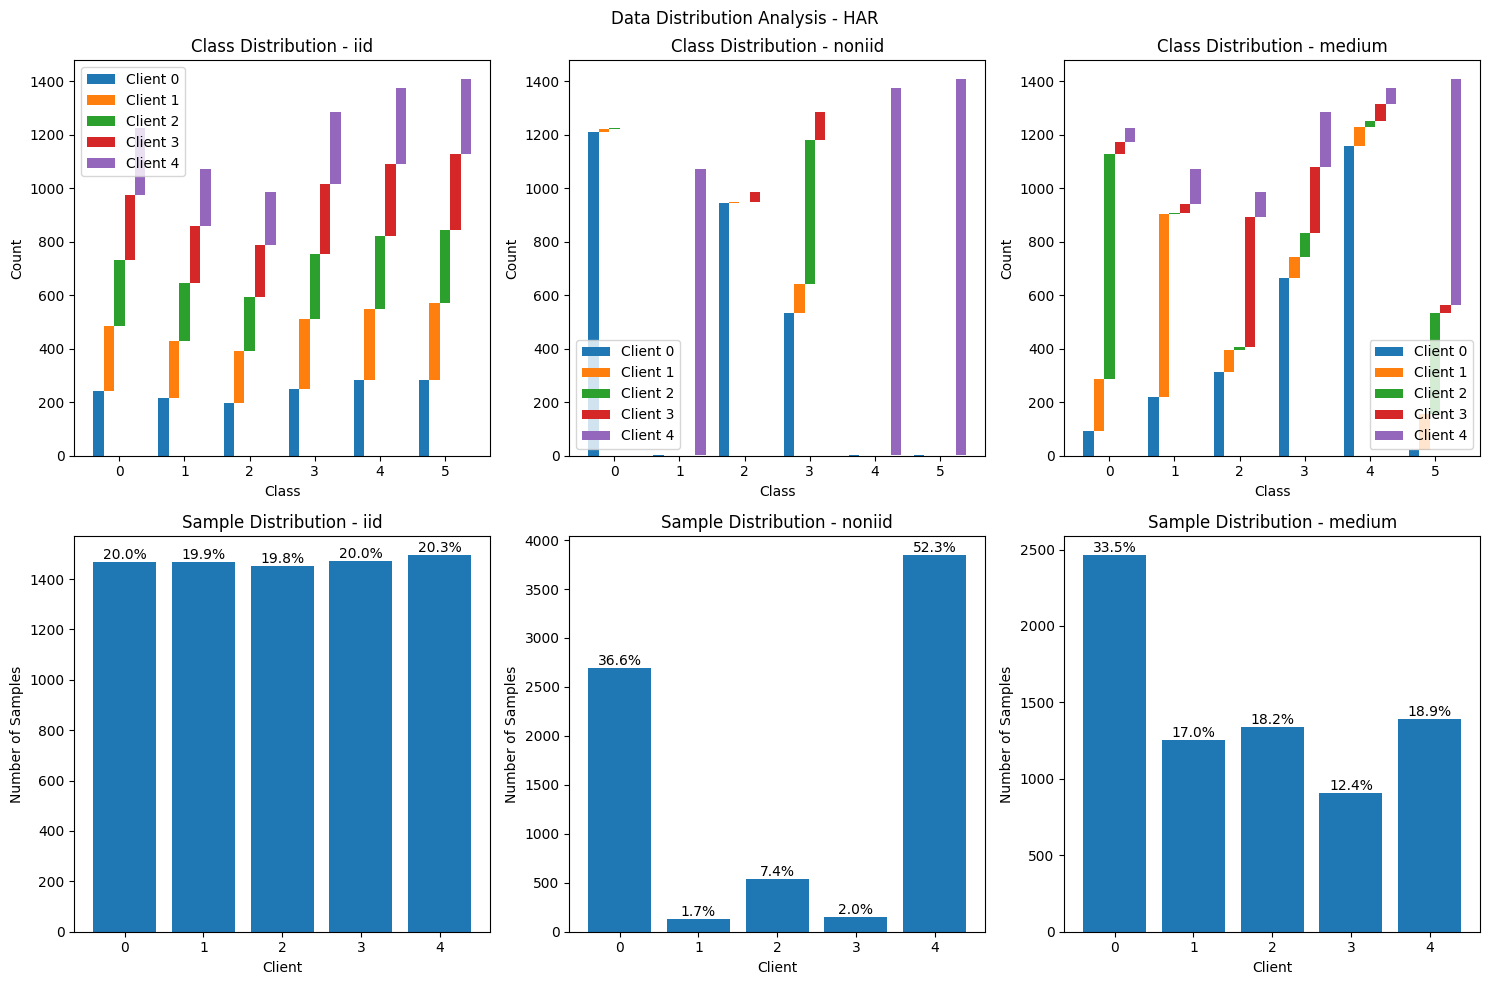

In [6]:
from utils.partitions_visualization import print_partition_stats, plot_data_distribution

# Print detailed statistics
print_partition_stats(partitions, "HAR")

# Create comprehensive visualization
fig = plot_data_distribution(partitions, "HAR")
plt.show()

In [7]:
from models.config import get_tinyprop_config
config = get_tinyprop_config("har")
print("\nModel Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

# Initialize model parameters
tinyprop_params = config["tinyprop_params"]
print("\nTinyProp Parameters:")
print(f"S_min: {tinyprop_params.S_min}")
print(f"S_max: {tinyprop_params.S_max}")
print(f"zeta: {tinyprop_params.zeta}")
print(f"number_of_layers: {tinyprop_params.number_of_layers}")


Model Configuration:
tinyprop_params: <models.tinyProp.TinyPropParams object at 0x00000205F4B0CC10>
optimizer: {'type': 'sgd', 'lr': 0.005, 'momentum': 0.9}
lr_scheduler: {'type': 'cosine', 'T_max': 50, 'eta_min': 1e-05}
gradient_clip: 1.0
batch_size: 32
num_epochs: 1
quantization: {'bits': 8, 'enabled': True}

TinyProp Parameters:
S_min: 0.5
S_max: 0.95
zeta: 0.5
number_of_layers: 5


In [ ]:
from clients.aggregators import sparse_fedavg_aggregate
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Run training
    model, accuracy_list, flops_list, mem_list, comm_list, sparsity_list, \
    avg_grad_norm_list, avg_phi_list, skipped_batches_list, \
    effective_compute_ratio_list, client_eval_history, compression_ratio_list, \
    quantization_errors, avg_scale_factors, history = federated_training(
        client_datasets=client_datasets,
        model_name='har',
        testset=testset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=100,
        early_stopping_delta=0.001,
        csv_log_path=f'results/har_5cl_{partition_name}.csv',
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000,
        quantization_bits=8,  # Add quantization bits parameter
        save_dir='results',  # Add save directory for logs
        save_interval=1  # Save metrics every round
    )
    
    # Store quantization metrics in history
    history['quantization_errors'] = quantization_errors
    history['avg_scale_factors'] = avg_scale_factors
    
    return model, history

# Update the config to include quantization parameters
config = get_tinyprop_config('har')
config['quantization_bits'] = 8  # Add quantization bits to config

partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, history = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'history': history,
            'quantization_metrics': {
                'errors': history['quantization_errors'],
                'scale_factors': history['avg_scale_factors']
            }
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue




Starting training for IID partition...

Training on partition: IID

Round 1/100
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Batch 5] Debug Info:
  - Loss: 1.7713
  - Loss Change: 0.0000
  - Relative Loss Change: 0.0000
  - Dynamic Threshold: 0.2000
  - Current phi_k: 0.4561
  - Current phi_max: 0.9900
  - Layer Sparsity: 0.5000
  - Skip Ratio: 0.2000
  - Current Skip Ratio: 0.2000
  - Should Skip: False
[Debug][Batch 5] Loss: 1.8300
[Debug][Batch 5] Loss Change: 0.0586
[Debug][Batch 5] Relative Loss Change: 0.0331
[Debug][Batch 5] Phi Update: -0.0033
[Debug][Batch 5] New phi_k: 0.4534
[Debug] phi_k_history: [0.29995804428463346, 0.37992664062065507, 0.37836187025116924, 0.45605568851270284, 0.45340694214076366]

[Batch 10] Debug In